# Amin Mottaghi -- S3

## 1.1 Ray-Tracing Examples in python


###  Example 1 : Refraction at a planar boundary

In [299]:
from math import pi, tan
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

In [300]:
op = 0.1 # output plane 
ti = 45 # incident degree
ti_rad = ti * pi/180 # converting incident degree into radians
x0 = 0 # the first point on the first plane
x1 = 0.03 # the second point on the interference

y0 = 0.02 # [m] height's of the first ray
y1 = y0 + tan(ti_rad)*x1
v1 = np.array([y1, ti_rad]) # first vector

x_ = np.array([x0, x1])
y_ = np.array([y0, y1])
# plt.figure()
# plt.plot(x_,y_, 'r')
# plt.xlim(0, 0.1)
# plt.ylim(0, 0.1)

In [301]:
# Refraction on the interference
n1 = 1 # refractive index of the first environment
n2 = 1.5 # refractive index of the second environment
M = np.array([[1, 0],
              [0, n1/n2]])  # Refraction matrice
v2 = M @ v1 # creating second vector

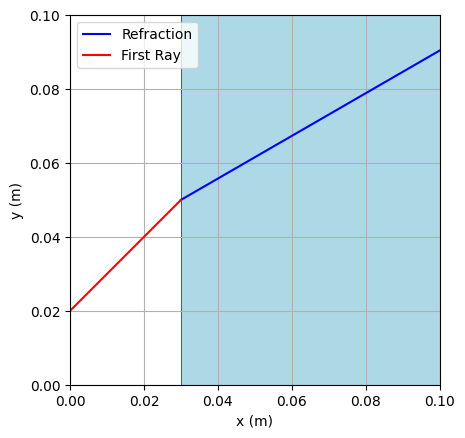

In [302]:
# Propagation from interface to the output plane (using propagation matrice)
yy0 = v2[0]
xx0 = x1
tt0 = v2[1]
v3 = np.array([x1, op])
d = op - x1 # Propagation distance
yy1 = yy0 + tan(tt0)*d  # calculating the final height
xx1 = op



# Create a square: (x, y) bottom-left corner, width, height
square = Rectangle((0.03, 0.0), 0.10, 0.10, 
                   edgecolor='blue', facecolor='lightblue', lw=0.5)

x__ = np.array([xx0, xx1])
y__ = np.array([yy0, yy1])
plt.figure()
plt.plot(x__,y__, 'b', label = 'Refraction')
plt.plot(x_,y_, 'r', label = 'First Ray')
plt.xlim(0, 0.1)
plt.ylim(0, 0.1)
plt.xlabel('x (m)')
plt.ylabel('y (m)')

# Get current axes and add the rectangle
ax = plt.gca()
ax.add_patch(square)

# Optional: set square aspect or grid
ax.set_aspect('equal')   # if you want true square proportions
plt.grid(True)
plt.legend()
plt.show()

### Example 2 : Refraction at the transparent slab

In [303]:
z0 =  0.02 # first height
ti = 45 # first degree
tt = ti * pi/180 # degree to radians transformer
zi = 0.04 # first interface
y1 = z0 + tan(tt) * zi
xp = [0, zi] 
yp = [z0, y1]
v1 = np.array([y1, tt]) # creating y1, tt as an array
# plt.plot(xp, yp)
# plt.xlim(0, 0.1)
# plt.ylim(0, 0.1)

In [304]:
## Refraction at the first plane
n1 = 1
n2 = 1.5
d = 0.005 # thickness
M1 = np.array([[1, 0], 
              [0, n1/n2]])  # transformation matrix
v2 = M1 @ v1
y2 = y1 + tan(v2[1]) * d
# ploting
xpp = [zi, zi + d]
ypp = [y1, y2]

# plt.plot(xp, yp, xpp, ypp)
# plt.xlim(0, 0.1)
# plt.ylim(0, 0.1)

In [305]:
## Refraction at the second plane
n1 = 1.5
n2 = 1
M2 = np.array([[1, 0],
               [0, n1/n2]])
v3 = M @ v2
zii = zi + d + 0.95
y3 = y2 + tan(tt) * zii
xppp = [zi + d, zii]
yppp = [y2, y3]

# plt.plot(xp, yp, xpp, ypp, xppp, yppp, 'r')
# plt.xlim(0, 0.1)
# plt.ylim(0, 0.1)

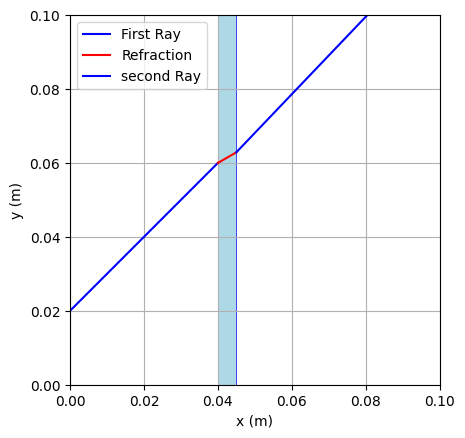

In [306]:
# Create a square: (x, y) bottom-left corner, width, height
square = Rectangle((zi, 0.0), d, 0.1,
                   edgecolor='blue', facecolor='lightblue', lw=0.5)

plt.figure()
plt.plot(xp,yp, 'b', label = 'First Ray')
plt.plot(xpp,ypp, 'r', label = 'Refraction')
plt.plot(xppp, yppp, 'b', label = 'second Ray')
plt.xlim(0, 0.1)
plt.ylim(0, 0.1)
plt.xlabel('x (m)')
plt.ylabel('y (m)')

# Get current axes and add the rectangle
ax = plt.gca()
ax.add_patch(square)

# Optional: set square aspect or grid
ax.set_aspect('equal')   # if you want true square proportions
plt.grid(True)
plt.legend()
plt.show()

### Example 3 : Refraction of a bundle of parallel rays from an extended source at a planar interface

In [307]:
y0 = np.linspace(0.01, 0.03, 20)
ti = 45
tt = ti * pi/180
zi = 0.03
y1 = y0 + tan(tt) * zi
yp = [y0, y1]
xp = [np.zeros_like(y0), np.full_like(y1, zi)]
zii = 0.1
# plt.figure()
# plt.plot(xp, yp, 'b')
# plt.xlim(0, 0.1)
# plt.ylim(0, 0.1)
# plt.xlabel('x (m)')
# plt.ylabel('y (m)')


In [308]:
n1 = 1
n2 = 1.5
M = np.array([[1, 0],
              [0, n1/n2]])
theta1 = tan(tt) * np.ones_like(y1)   # incident slope for all rays
v1 = np.vstack([y1, theta1])    
v2 = M @ v1

y3 = v2[0] + v2[1] * (zii - zi) 

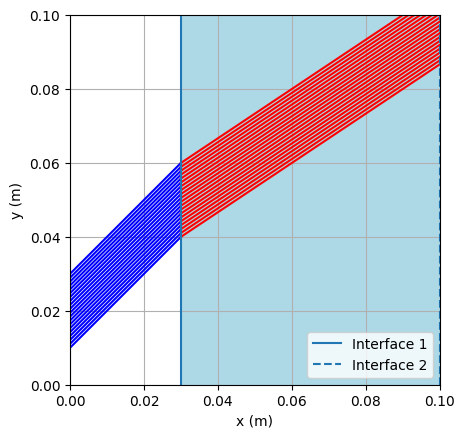

In [309]:
xpp = np.array([np.full_like(y0, zi), np.full_like(y0, zii)])  
ypp = np.array([y1, y3])  


square = Rectangle((zi, 0.0), zii - zi, 0.10, 
                   edgecolor='blue', facecolor='lightblue', lw=0.5)

# Plotting (unchanged except adding second interface line)
plt.figure()
plt.plot(xp, yp, 'b')   
plt.plot(xpp, ypp, 'r')
plt.xlim(0, 0.1)
plt.ylim(0, 0.1)
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.axvline(x=zi, linestyle='-', label='Interface 1')
plt.axvline(x=zii, linestyle='--', label='Interface 2')   # added for clarity

ax = plt.gca()
ax.add_patch(square)
ax.set_aspect('equal')
plt.grid(True)
plt.legend()
plt.show()

In [310]:
y0 = 0.05
t = np.arange(-20, 20, 5)
tt = t * pi/180
zi = 0.04 # first interface
zii = 0.1 # second interface
y1 = y0 + np.tan(tt) * zi

xp = [ np.zeros_like(y1), np.full_like(y1, zi)]
yp = [np.full_like(y1, y0), y1]
# plt.figure()
# plt.plot(xp, yp, 'b')
# plt.xlim(0, 0.1)
# plt.ylim(0, 0.1)
# plt.xlabel('x (m)')
# plt.ylabel('y (m)')

In [311]:
# Refraction 
n1 = 1
n2 = 1.5
M = np.array([[1, 0],
              [0, n1/n2]])
theta1 = np.tan(tt) * np.ones_like(y1)   # incident angel for all rays
v1 = np.vstack([y1, theta1])    
v2 = M @ v1
y3 = v2[0] + np.tan(tt) * (zii - zi)

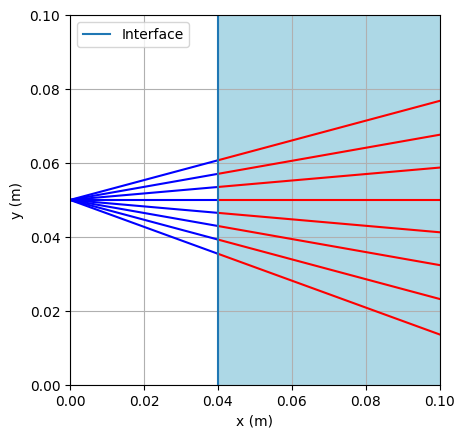

In [312]:
xpp = np.array([np.full_like(y0, zi), np.full_like(y0, zii)])  
ypp = np.array([y1, y3])  

square = Rectangle((zi, 0), zii - zi, 0.10,
                   edgecolor='blue', facecolor='lightblue', lw=0.5)


# plotting
plt.figure()
plt.plot(xp, yp, 'b')   
plt.plot(xpp, ypp, 'r')
plt.xlim(0, 0.1)
plt.ylim(0, 0.1)
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.axvline(x=zi,linestyle='-', label='Interface')

# Get current axes and add the rectangle
ax = plt.gca()
ax.add_patch(square)

# Optional: set square aspect or grid
ax.set_aspect('equal')   # if you want true square proportions
plt.grid(True)
plt.legend()
plt.show()

